In [1]:
import sys
sys.path.append('../')

import json
import pickle
import copy 
import random 
import glob

from tqdm.auto import trange
import tqdm_joblib
from joblib import Parallel, delayed

import numpy as np
import jax.numpy as jnp
import jax.random as jrandom
import jax
jax.config.update("jax_enable_x64", True)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.distributions import constraints

from jug.engine.session import TimingSession

from Atlas.data import PTA_Data
from Atlas.nMatrix import TM, marg_TM
from Atlas.signals.uncorrelated.base import Uncorrelated, SuperSignal
from Atlas.signals.correlated.base import Correlated
from Atlas import parameterized
from  Atlas.signals.timing.base import build_multi_psr_timing_model, MultiPsrTimingModel
from Atlas.signals.timing.base import setup_timing_model, _timing_model_svd

from Atlas.signals import signals_utils as sutils
import Atlas.utils as atlas_utils
import Atlas.signals.uncorrelated.utils as unc_utils
import Atlas.signals.correlated.utils as cor_utils


# import MultiHMCGibbs

from Atlas.samplers.canetoadracing import MultiHMCGibbs, MultiHMCGibbsWithAnalytic, AnalyticRhoTransition

%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
hist_settings = dict(
    bins = 'auto',
    histtype = 'step', 
    lw = 3,
    density = True
)

plt.style.use('default')
def figsize(scale, wc = 1, hc = 1):
    fig_width_pt = 513.17 #469.755                  # Get this from LaTeX using \the\textwidth
    inches_per_pt = 1.0/72.27                       # Convert pt to inch
    golden_mean = (np.sqrt(5.0)-1.0)/2.0            # Aesthetic ratio (you could change this)
    fig_width = fig_width_pt*inches_per_pt*scale    # width in inches
    fig_height = fig_width*golden_mean              # height in inches
    fig_size = [wc * fig_width,hc * fig_height]
    return fig_size
plt.rcParams.update(plt.rcParamsDefault)

params = {#'backend': 'pdf',
        'axes.labelsize': 12,
        'lines.markersize': 4,
        'font.size': 10,
        'xtick.major.size':6,
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "xtick.major.top": True, 
        "xtick.minor.top": True,
        "ytick.minor.visible": True, 
        "ytick.major.right": True, 
        "ytick.minor.right": True,
        "ytick.direction": "in",
        "xtick.direction": "in",
        'xtick.minor.size':3,  
        'ytick.major.size':6,
        'ytick.minor.size':3, 
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'xtick.minor.width':0.5,
        'ytick.minor.width':0.5,
        'lines.markeredgewidth':1,
        'axes.linewidth':1.2,
        'legend.fontsize': 7,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'savefig.dpi':200,
        'path.simplify':True,
        'font.family': 'serif',
        'font.serif':'Times',
        # "text.usetex": True,
        #'text.latex.preamble': [r'\usepackage{amsmath}'],
        'text.usetex':False,
        'figure.figsize': figsize(0.5, 1, 1)}
plt.rcParams.update(params)
plt.rcParams['font.family'] = 'STIXGeneral'  # Closely matches Computer Modern
plt.rcParams['mathtext.fontset'] = 'stix'    # Use STIX for math

# Loading data

## Option 1: To test the full capability of `ATLAS`, we only need par and tim files.

### We are using the `enterprise` pulsar object. This will be replaced by an in-house object very soon.

In [3]:
from enterprise.pulsar import Pulsar

In [4]:
pnames = ['B1855+09', 'B1937+21', 'B1953+29', 'J0023+0923', 'J0030+0451', 'J0340+4130', 'J0406+3039', 
'J0437-4715', 'J0509+0856', 'J0557+1551', 'J0605+3757', 'J0610-2100', 'J0613-0200', 'J0636+5128', 
'J0645+5158', 'J0709+0458', 'J0740+6620', 'J0931-1902', 'J1012+5307', 'J1012-4235', 'J1022+1001', 
'J1024-0719', 'J1125+7819', 'J1312+0051', 'J1453+1902', 'J1455-3330', 'J1600-3053', 'J1614-2230', 
'J1630+3734', 'J1640+2224', 'J1643-1224', 'J1705-1903', 'J1713+0747', 
'J1719-1438', 'J1730-2304', 
'J1738+0333', 'J1741+1351', 'J1744-1134', 'J1745+1017', 'J1747-4036', 'J1751-2857', 'J1802-2124', 
'J1811-2405', 'J1832-0836', 'J1843-1113', 'J1853+1303', 'J1903+0327', 'J1909-3744', 'J1910+1256', 
'J1911+1347', 'J1918-0642', 'J1923+2515', 'J1944+0907', 'J1946+3417', 'J2010-1323', 'J2017+0603', 
'J2033+1734', 'J2043+1711', 'J2124-3358', 'J2145-0750', 'J2214+3000', 'J2229+2643', 'J2234+0611', 
'J2234+0944', 'J2302+4442', 'J2317+1439', 'J2322+2057']
len(pnames)

67

In [5]:
parfiles_ref = sorted(glob.glob('../data/NG15/partim/par/*.par'))
timfiles_ref = sorted(glob.glob('../data/NG15/partim/tim/*.tim'))

### Filter the par and tim files to remove "ao-only" files

In [6]:
parfiles = []
for pname in pnames:
    for p in parfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            parfiles.append(p)

timfiles = []
for pname in pnames:
    for p in timfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            timfiles.append(p)

In [7]:
assert len(parfiles) == len(pnames)

In [8]:
Npulsars = len(pnames) # how many pulsars do you want?
Npulsars

67

In [9]:
# def doit(pidx):
#     return Pulsar(parfiles[pidx], timfiles[pidx], sort=True, ephem='DE440', timing_package='PINT')
# with tqdm_joblib.tqdm_joblib(desc="PINT Loading...", total=len(parfiles)) as progress_bar:
#     psrs = Parallel(n_jobs=24)(delayed(doit)(i) for i in range(len(parfiles)))
#     # psrs = Parallel(n_jobs=24)(delayed(doit)(i) for i in range(1))

# with open('../data/NG15/NG15_v1p1_final_pint_psrs_sorted.pkl', 'wb') as fout:
#     pickle.dump(psrs, fout)

In [10]:
with open('../data/NG15/NG15_v1p1_final_pint_psrs_sorted.pkl', 'rb') as fin:
    psrs = pickle.load(fin)
psrs = [psr for psr in psrs if psr.name != 'J1713+0747']

In [11]:
with open('../data/NG15/15yr_wn_dict.json', 'r') as fin:
    noise_dict = json.load(fin)

In [12]:
chosen_pidx = 0 #np.argmin([len(psr.toas) for psr in psrs])
chosen_pidx 

0

In [13]:
psrs = psrs[chosen_pidx :chosen_pidx +1]

In [14]:
len(psrs)

1

In [15]:
psrs[0].name

'B1855+09'

In [16]:
timfiles[chosen_pidx :chosen_pidx +1]

['../data/NG15/partim/tim/B1855+09_PINT_20220301.nb.tim']

## Option 2: If you do not want to vary the timing model params, use the pre-made 15 year pulsar objects.

In [17]:
# from enterprise.pulsar import FeatherPulsar
# import glob

# feather_files = glob.glob('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/*.feather')
# psrs = []
# for feather_file in feather_files:
#     psr = FeatherPulsar.read_feather(feather_file)
#     psrs.append(psr)

# with open('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/15yr_wn_dict.json', 'r') as fin:
#     noise_dict = json.load(fin)

# Model Construction

## White Noise Model

In [18]:
choices = {
    1: {'white noise without backend (for simulation studies)' : TM.NoBackendWhiteCov},
    2: {'Timing model marginalized white noise without backend (for simulation studies)' : marg_TM.Marg_NoBackendWhiteCov},
    3: {'white noise with backend (for real data)' : TM.WhiteCov},
    4: {'Timing model marginalized white noise with backend (for real data)' : marg_TM.Marg_WhiteCov}
}

In [19]:
your_choice = 3

In [20]:
white_noise_model = list(choices[your_choice].values())[0]
white_noise_model

Atlas.nMatrix.TM.WhiteCov

In [21]:
data = PTA_Data(psrs, 
                fixed_wn = False, 
                fixed_res = False, 
                linear_timing = True)

N_list = []
pbar = trange(len(psrs))
for pidx in pbar:
    psr = data.psrs[pidx]
    pbar.set_description(f"Construncting White Noise Cov Matrix {psr.name}")
    N_list.append(white_noise_model(psr)
)
wn_model = TM.MultiPulsarWhiteCov(psrs = psrs, cov_matrices = N_list)
data.add_white_noise_cov(wn_model)

  0%|          | 0/1 [00:00<?, ?it/s]

In [22]:
SAMPLE = ['F0', 'F1'] #psrs[0].fitpars[1:] #['F0', 'F1']
tm_model = build_multi_psr_timing_model(parfiles[chosen_pidx :chosen_pidx + 1], 
                                        timfiles[chosen_pidx :chosen_pidx + 1], 
                                        SAMPLE, 
                                        load_how_many_in_parallel = 24,
                                        data = data)
# data.add_timing_design_matrix(tm_model.Mmats)
svd_norm_mmat = _timing_model_svd(psrs[0].Mmat)
data.add_timing_design_matrix([svd_norm_mmat])

Loading the par and tim files...:   0%|          | 0/1 [00:00<?, ?it/s]

E0625 14:20:57.097394  802527 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 17.77GiB (19076825088 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0625 14:20:57.097593  802527 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 15.99GiB (17169141760 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0625 14:20:57.097775  802527 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 14.39GiB (15452227584 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0625 14:20:57.097953  802527 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 12.95GiB (13907004416 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0625 14:20:57.098130  802527 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 11.66GiB (12516303872 by

JAX 64-bit mode automatically enabled successfully.
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA


/home/aidengundersen/jug/jug/io/clock.py:249: UserWarning: Clock file 'ao2gps.clk': 1167 TOA(s) before clock data start (MJD 50155.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)
/home/aidengundersen/jug/jug/io/clock.py:249: UserWarning: Clock file 'ao2gps.clk': 1596 TOA(s) after clock data end (MJD 59079.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)
/home/aidengundersen/jug/jug/io/clock.py:249: UserWarning: Clock file 'gps2gpst.clk': 5116 TOA(s) after clock data end (MJD 55559.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)


[FITTER] noise_config was None, auto-detecting from par file
[SETUP] Building RED NOISE basis: 60 columns
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA


In [23]:
stochastic_res = jnp.concat(data.raw_residuals)

### Initial white noise guess

In [24]:
# theta0_wn = wn_model.prior_draw()
theta0_wn = wn_model.params_dict_to_vector(noise_dict)
theta0_wn[:5]

Array([ 1.11593531,  1.00004904,  1.04311402,  1.11184323, -7.56416433],      dtype=float64)

In [25]:
data.fix_white_noise_params(theta0_wn)

In [26]:
data.pta_tspan / 86400 / 365.25

15.585070202331154

## Red Noise Model

In [27]:
non_gwb_nfreqs = 30

### Non-GWB Model

#### Choose your PSD model

In [28]:
# Example:
# chosen_psd_model_nongwb, helper_dictionary_nongwb = unc_utils.varied_gamma_pl(renorm_const = 1)
chosen_psd_model_nongwb, helper_dictionary_nongwb = unc_utils.spectrum(renorm_const = 1, crn_bins = non_gwb_nfreqs)

In [29]:
sig_unc = Uncorrelated(name='cor', 
                    nfreqs=non_gwb_nfreqs, 
                    halflog10_rho_range=(-9,-2),
                    data = data,
                    use_pulsar_tspan = False) #NOTE: pay attention to this!!!! Is this what you want?

### The user should not see this in the final version, but for now you need to see this!

In [30]:
signal_helper = {
    'shared_basis': { #shared basis does not mean the nfreqs are the same between signals.
                    #It means that one basis includes the other one.
    'signal_list': [sig_unc], 
    'index_of_signal_used_for_basis': 0,
    },

    'separate': {
        'signal_list': []
        },
    'order': 'cor',
    }

In [31]:
sig = SuperSignal(signal_helper = signal_helper, 
                data=data,
)

### `sig.get_helpers` updates the white noise covaraince matrix

In [32]:
from enterprise_extensions import blocks
from enterprise.signals import signal_base, gp_signals
from enterprise.pulsar import Pulsar
from astropy.time import TimeDelta
# from pint.simulation import make_fake_toas_fromMJDs
import astropy.units as u
# from pint.models import get_model

from enterprise_extensions import sampler
from enterprise.signals import parameter
from enterprise.signals import gp_priors

Optional mpi4py package is not installed.  MPI support is not available.


In [33]:
Tspan = data.pta_tspan
Tspan/(365.25 * 86400)

15.585070202331154

In [37]:
s = gp_signals.TimingModel(
    use_svd=True,
    normed=True)
s += blocks.white_noise_block(
    vary=True,
    inc_ecorr=True,
    gp_ecorr=False,
    select='backend',
    tnequad=False,
)

# log10_A = parameter.Uniform(-18., -11.)('log10A')
# gamma = parameter.Uniform(0., 7.)('gamma')

# s+= gp_signals.FourierBasisGP(
#     spectrum=gp_priors.powerlaw(log10_A=log10_A, gamma = gamma),
#     modes = sig_unc.freqs,
#     # components = len(sig_unc.freqs),
#     Tspan=Tspan,
#     name="red_noise",
# )
log10_rho = parameter.Uniform(-9., -2., size=len(sig_unc.freqs))
s+= gp_signals.FourierBasisGP(
    spectrum=gp_priors.free_spectrum(log10_rho=log10_rho),
    components=len(sig_unc.freqs),
    modes = sig_unc.freqs,
    Tspan=Tspan,
    # name="red_noise",
)

pta = signal_base.PTA(
    [s(p) for p in psrs], signal_base.LogLikelihoodDenseCholesky
)

In [39]:
pta.get_basis()[0][0, :10]

array([-0.02494906,  0.02490892, -0.0190668 , -0.01236388, -0.01306706,
        0.00840879, -0.00375493,  0.01253834,  0.00555094,  0.00661795])

In [40]:
sig.get_Fmat_concat[0, :10]

Array([-0.02494906,  0.02490892, -0.0190668 , -0.01236388, -0.01306706,
        0.00840879, -0.00375493,  0.01253834,  0.00555094,  0.00661795],      dtype=float64)

In [41]:
def _timing_model_svd(M):
    """Create an more stable basis for the timing model design matrix using SVD.

    This function is used to create a basis U which represents the timing model
    design matrix M and normalizes each of the basis vectors. This can be used
    as a more stable alternative to M in timing model marginalization. 

    This takes an SVD of the design matrix M, and returns only the left singular 
    vectors U as the new basis. This works since during the marginalization process,
    the singular values aren't important when integrating over the whole range of
    timing model coefficients. Likewise, the right singular vectors are only
    used to project into the original basis, which we do not need.

    Parameters
    ----------
    M : array
        The design matrix for the timing model. [ntoas, nparams]

    Returns
    -------
    array
        The left singular vectors of the design matrix M, which can be used as a more
        stable basis for timing model marginalization. [ntoas, nparams]
    """
    U,C,V = np.linalg.svd(M, full_matrices=False)
    # Return just the left singular vector.
    # The singular values are a weighting factor that isn't important when marginalizing.
    # the right singular vectors are used to project into the original basis, which isn't 
    # important for marginalization either. 
    return U

In [42]:
TNT, TNr, rNr, logdetN = sig.get_helpers(reff = stochastic_res, white_noise_params=theta0_wn)
TNT.shape, TNr.shape, rNr.shape, logdetN.shape

((1, 226, 226), (1, 226), (1, 1), (1,))

In [50]:
pta.get_TNr(noise_dict)[0][:10]

array([-8469384.5158076 ,  5428122.17539821,  1044205.79904702,
        -419167.7213056 ,  -543415.72498102,   400409.73829441,
        -166790.37991611,  -421514.50590837, -4977963.96415101,
        1778127.2316361 ])

In [48]:
TNr[0, :10]

Array([-8469384.51580761,  5428122.17539821,  1044205.79904702,
        -419167.7213056 ,  -543415.72498101,   400409.73829442,
        -166790.3799161 ,  -421514.50590837, -4977963.96415101,
        1778127.23163611], dtype=float64)

In [54]:
TNr_ent[:10]

array([ 3043513.29730832,  3137607.44357734,  1614064.39297948,
       -1140567.71600369, -1033714.57885251,  2385024.07622927,
        3936634.10205698, -8469385.05122126,  2078703.61838116,
         702526.06576482])

In [43]:
ll, ul = wn_model.get_prior_bounds() #white noise prior bounds
ll[:5], ul[:5]

(Array([ 0.01,  0.01,  0.01,  0.01, -9.  ], dtype=float64),
 Array([10., 10., 10., 10., -5.], dtype=float64))

In [43]:
o = parameterized.SinglePulsarRedNoise(
            int_bins = non_gwb_nfreqs,
            f_intrin = sig_unc.freqs,
            df = 1/Tspan,
            Tspan = Tspan, 
            renorm_const = 1,
            # ---- non-GWB intrinsic red noise (optional) ----
            irn_psd_func=chosen_psd_model_nongwb,
            irn_helper_dictionary=helper_dictionary_nongwb,
            )
sig.add_model(o)

In [44]:
x0 = o.make_initial_guess(jrandom.key(1273442)) #red noise model params
phi0 = o.get_phi_mat_full(x0) #red noise cov matrix
phi0.shape, x0.shape

((30, 1), (30,))

In [45]:
sig.get_Fmat_concat[0, :10]

Array([-0.02494906,  0.02490892, -0.0190668 , -0.01236388, -0.01306706,
        0.00840879, -0.00375493,  0.01253834,  0.00555094,  0.00661795],      dtype=float64)

In [46]:
psrs[0].Mmat[0, :10]

array([ 5.36210047e-03,  4.23101388e-07, -2.35794790e+00, -4.32963256e+00,
        6.03989756e-06,  9.37205186e-06,  1.31863846e+06, -1.62138644e+14,
        2.15989664e-03,  0.00000000e+00])

In [47]:
pta.get_basis()[0][0, :10]

array([-0.02494906,  0.02490892, -0.0190668 , -0.01236388, -0.01306706,
        0.00840879, -0.00375493,  0.01253834,  0.00555094,  0.00661795])

In [55]:
(sig.get_Fmat_concat / pta.get_basis()[0])[np.ix_(np.r_[0:10], np.r_[0:10])]

Array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]], dtype=float64)

In [51]:
with open('TNT_TNr.pkl', 'rb') as f:
    TNT_TNr_dict = pickle.load(f)

In [52]:
TNT_ent, TNr_ent = TNT_TNr_dict['B1855+09']

In [58]:
TNT_ent = TNT_ent[None, ...]
TNr_ent = TNr_ent[None, ...]

# Likelihood

### Reparameterized likelihood

In [59]:
z0 = jrandom.normal(jrandom.key(10098), shape = (sig.npsrs, sig.nmodes)) # re-parameterized coefficients

In [60]:
# lnprob0, coeff0 = sig.lnposterior_reparam(helpers = (TNT, TNr), 
#                                             red_params = x0, 
#                                             z = z0)
lnprob0, coeff0 = sig.lnposterior_reparam(helpers = (TNT_ent, TNr_ent), 
                                            red_params = x0, 
                                            z = jnp.zeros_like(z0))
lnprob0

Array(-1769.51109926, dtype=float64)

In [64]:
TNr_ent[0, :10]

array([ 3043513.29730832,  3137607.44357734,  1614064.39297948,
       -1140567.71600369, -1033714.57885251,  2385024.07622927,
        3936634.10205698, -8469385.05122126,  2078703.61838116,
         702526.06576482])

In [65]:
TNr[0, :10]

Array([-8469384.51580761,  5428122.17539821,  1044205.79904702,
        -419167.7213056 ,  -543415.72498101,   400409.73829442,
        -166790.3799161 ,  -421514.50590837, -4977963.96415101,
        1778127.23163611], dtype=float64)

In [70]:
sig.get_Fmat_concat[100, -10:]

Array([ 0.70081251,  0.71334552, -0.08132979, -0.99668725, -0.57589332,
        0.81752485,  0.9658781 , -0.2589971 , -0.90765548, -0.41971602],      dtype=float64)

In [71]:
pta.get_basis()[0][100, -10:]

array([ 0.70081251,  0.71334552, -0.08132979, -0.99668725, -0.57589332,
        0.81752485,  0.9658781 , -0.2589971 , -0.90765548, -0.41971602])

In [72]:
stochastic_res

Array([-1.57340607e-06, -1.71798787e-06, -8.38831411e-07, ...,
        2.22197622e-06,  1.93564911e-06,  2.50652552e-06], dtype=float64)

In [74]:
psrs[0].residuals

array([-1.57340607e-06, -1.71798787e-06, -8.38831411e-07, ...,
        2.22197622e-06,  1.93564911e-06,  2.50652552e-06], shape=(7758,))

In [61]:
lnprob0, coeff0 = sig.lnposterior_reparam(helpers = (TNT, TNr), 
                                            red_params = x0, 
                                            z = jnp.zeros_like(z0))
lnprob0

Array(-1803.42329701, dtype=float64)

In [42]:
def model(helpers):

    TNT, TNr = helpers

    z = numpyro.sample('z_tm_concat', dist.Normal().expand([sig.npsrs, sig.nmodes]))

    rn_params = numpyro.sample('half_log_10_rho', dist.Uniform(-10., -2.).expand([sig.npsrs, x0.shape[0]]))

    lnpost_val, a = sig.lnposterior_reparam(helpers=(TNT, TNr), red_params=rn_params, z=z)

    numpyro.deterministic('a', a)
    numpyro.factor('lnpost', lnpost_val)

In [43]:
nuts_kernel = numpyro.infer.NUTS(model=model)
mcmc = numpyro.infer.MCMC(sampler=nuts_kernel,
                          num_warmup=1000,
                          num_samples=5000,
                          num_chains=2,
                          )
mcmc.run(jrandom.key(12887), (TNT, TNr))
atlas_helpers_samples = mcmc.get_samples()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

In [44]:
nuts_kernel = numpyro.infer.NUTS(model=model)
mcmc = numpyro.infer.MCMC(sampler=nuts_kernel,
                          num_warmup=1000,
                          num_samples=5000,
                          num_chains=2,
                          )
mcmc.run(jrandom.key(12887), (TNT_ent, TNr_ent))
ent_helpers_samples = mcmc.get_samples()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

In [45]:
import numpy as np
from pyarrow import feather

def restore_value(x):
    """
    Restore a value that was saved by convert_value().
    If x is a dict with keys 'data' and 'shape', rebuild a NumPy array with that shape.
    If x is a list, convert it to a NumPy array.
    Otherwise, return x unchanged.
    """
    if isinstance(x, dict) and "data" in x and "shape" in x:
        arr = np.array(x["data"])
        try:
            return arr.reshape([int(el) for el in x["shape"]])
        except Exception as e:
            # In case the reshape fails, return the flat array.
            return arr
    elif isinstance(x, list):
        return np.array(x)
    else:
        return x

def load_chain(filepath):
    """
    Load MCMC samples from feather file.

    Parameters
    ----------
    filepath : str
        Local destination path to save feather file

    Returns
    -------
    samples : dict
        Dictionary of parameter samples from chain
    """

    # load data frame
    df_loaded = feather.read_feather(filepath)

    # First convert the DataFrame to a list of row dictionaries.
    records = df_loaded.to_dict(orient='records')[0]
    
    # Reconstruct the original dictionary.
    samples = {}
    for key, value in records.items():
        samples[key] = restore_value(value)
    return samples


In [46]:
prom_run_pta_tspan = load_chain('single_psrs.feather')
prom_run_psr_tspan = load_chain('B1855+09.feather')
prom_psr_names = np.load('prom_psr_names.npy')
prom_psr_ndx = np.where(prom_psr_names == data.psr_names[0])[0][0]

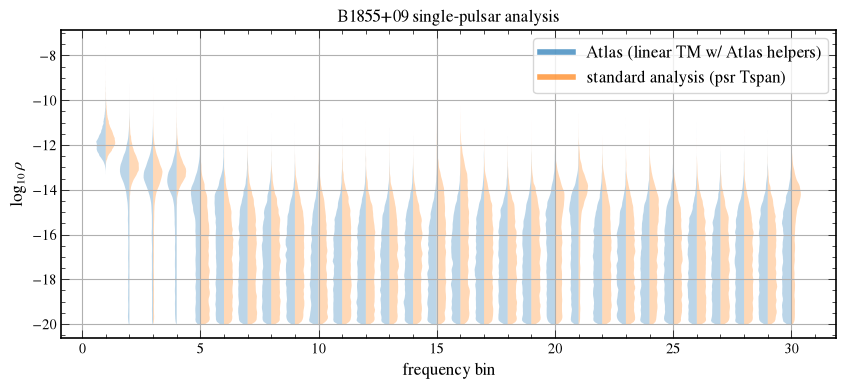

In [50]:
plt.figure(figsize=(10, 4))
plt.violinplot(dataset=2*np.array(atlas_helpers_samples['half_log_10_rho'])[:, 0],
               widths=0.8,
               showextrema=False,
               side='low',
               bw_method=0.05)
plt.violinplot(dataset=np.array(prom_run_psr_tspan['psr_params'])[:, 0],
               widths=0.8,
               showextrema=False,
               side='high',
               bw_method=0.05)
plt.plot([], [], color='C0', label='Atlas (linear TM w/ Atlas helpers)', lw=4, alpha=0.7)
plt.plot([], [], color='C1', label='standard analysis (psr Tspan)', lw=4, alpha=0.7)
plt.grid()
plt.xlabel('frequency bin')
plt.ylabel(r'$\log_{10}\rho$')
plt.title(f'{data.psr_names[0]} single-pulsar analysis')
plt.legend(loc='upper right', fontsize=12)
plt.show()

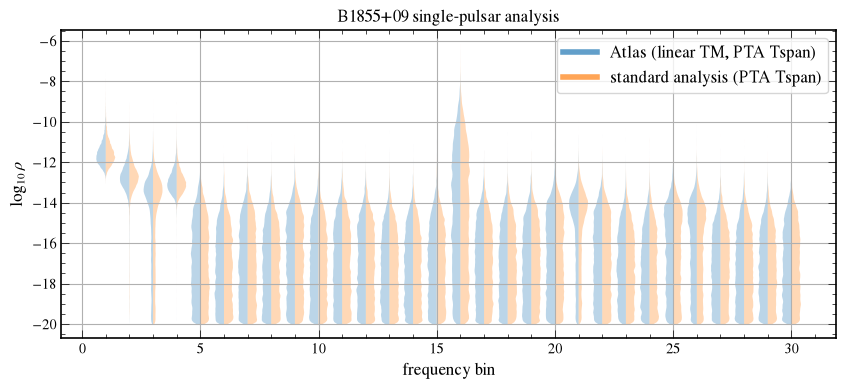

In [48]:
plt.figure(figsize=(10, 4))
plt.violinplot(dataset=2*np.array(ent_helpers_samples['half_log_10_rho'])[:, 0],
               widths=0.8,
               showextrema=False,
               side='low',
               bw_method=0.05)
plt.violinplot(dataset=np.array(prom_run_pta_tspan['psr_params'])[:, prom_psr_ndx],
               widths=0.8,
               showextrema=False,
               side='high',
               bw_method=0.05)
plt.plot([], [], color='C0', label='Atlas (linear TM, PTA Tspan)', lw=4, alpha=0.7)
plt.plot([], [], color='C1', label='standard analysis (PTA Tspan)', lw=4, alpha=0.7)
plt.grid()
plt.xlabel('frequency bin')
plt.ylabel(r'$\log_{10}\rho$')
plt.title(f'{data.psr_names[0]} single-pulsar analysis')
plt.legend(loc='upper right', fontsize=12)
plt.show()

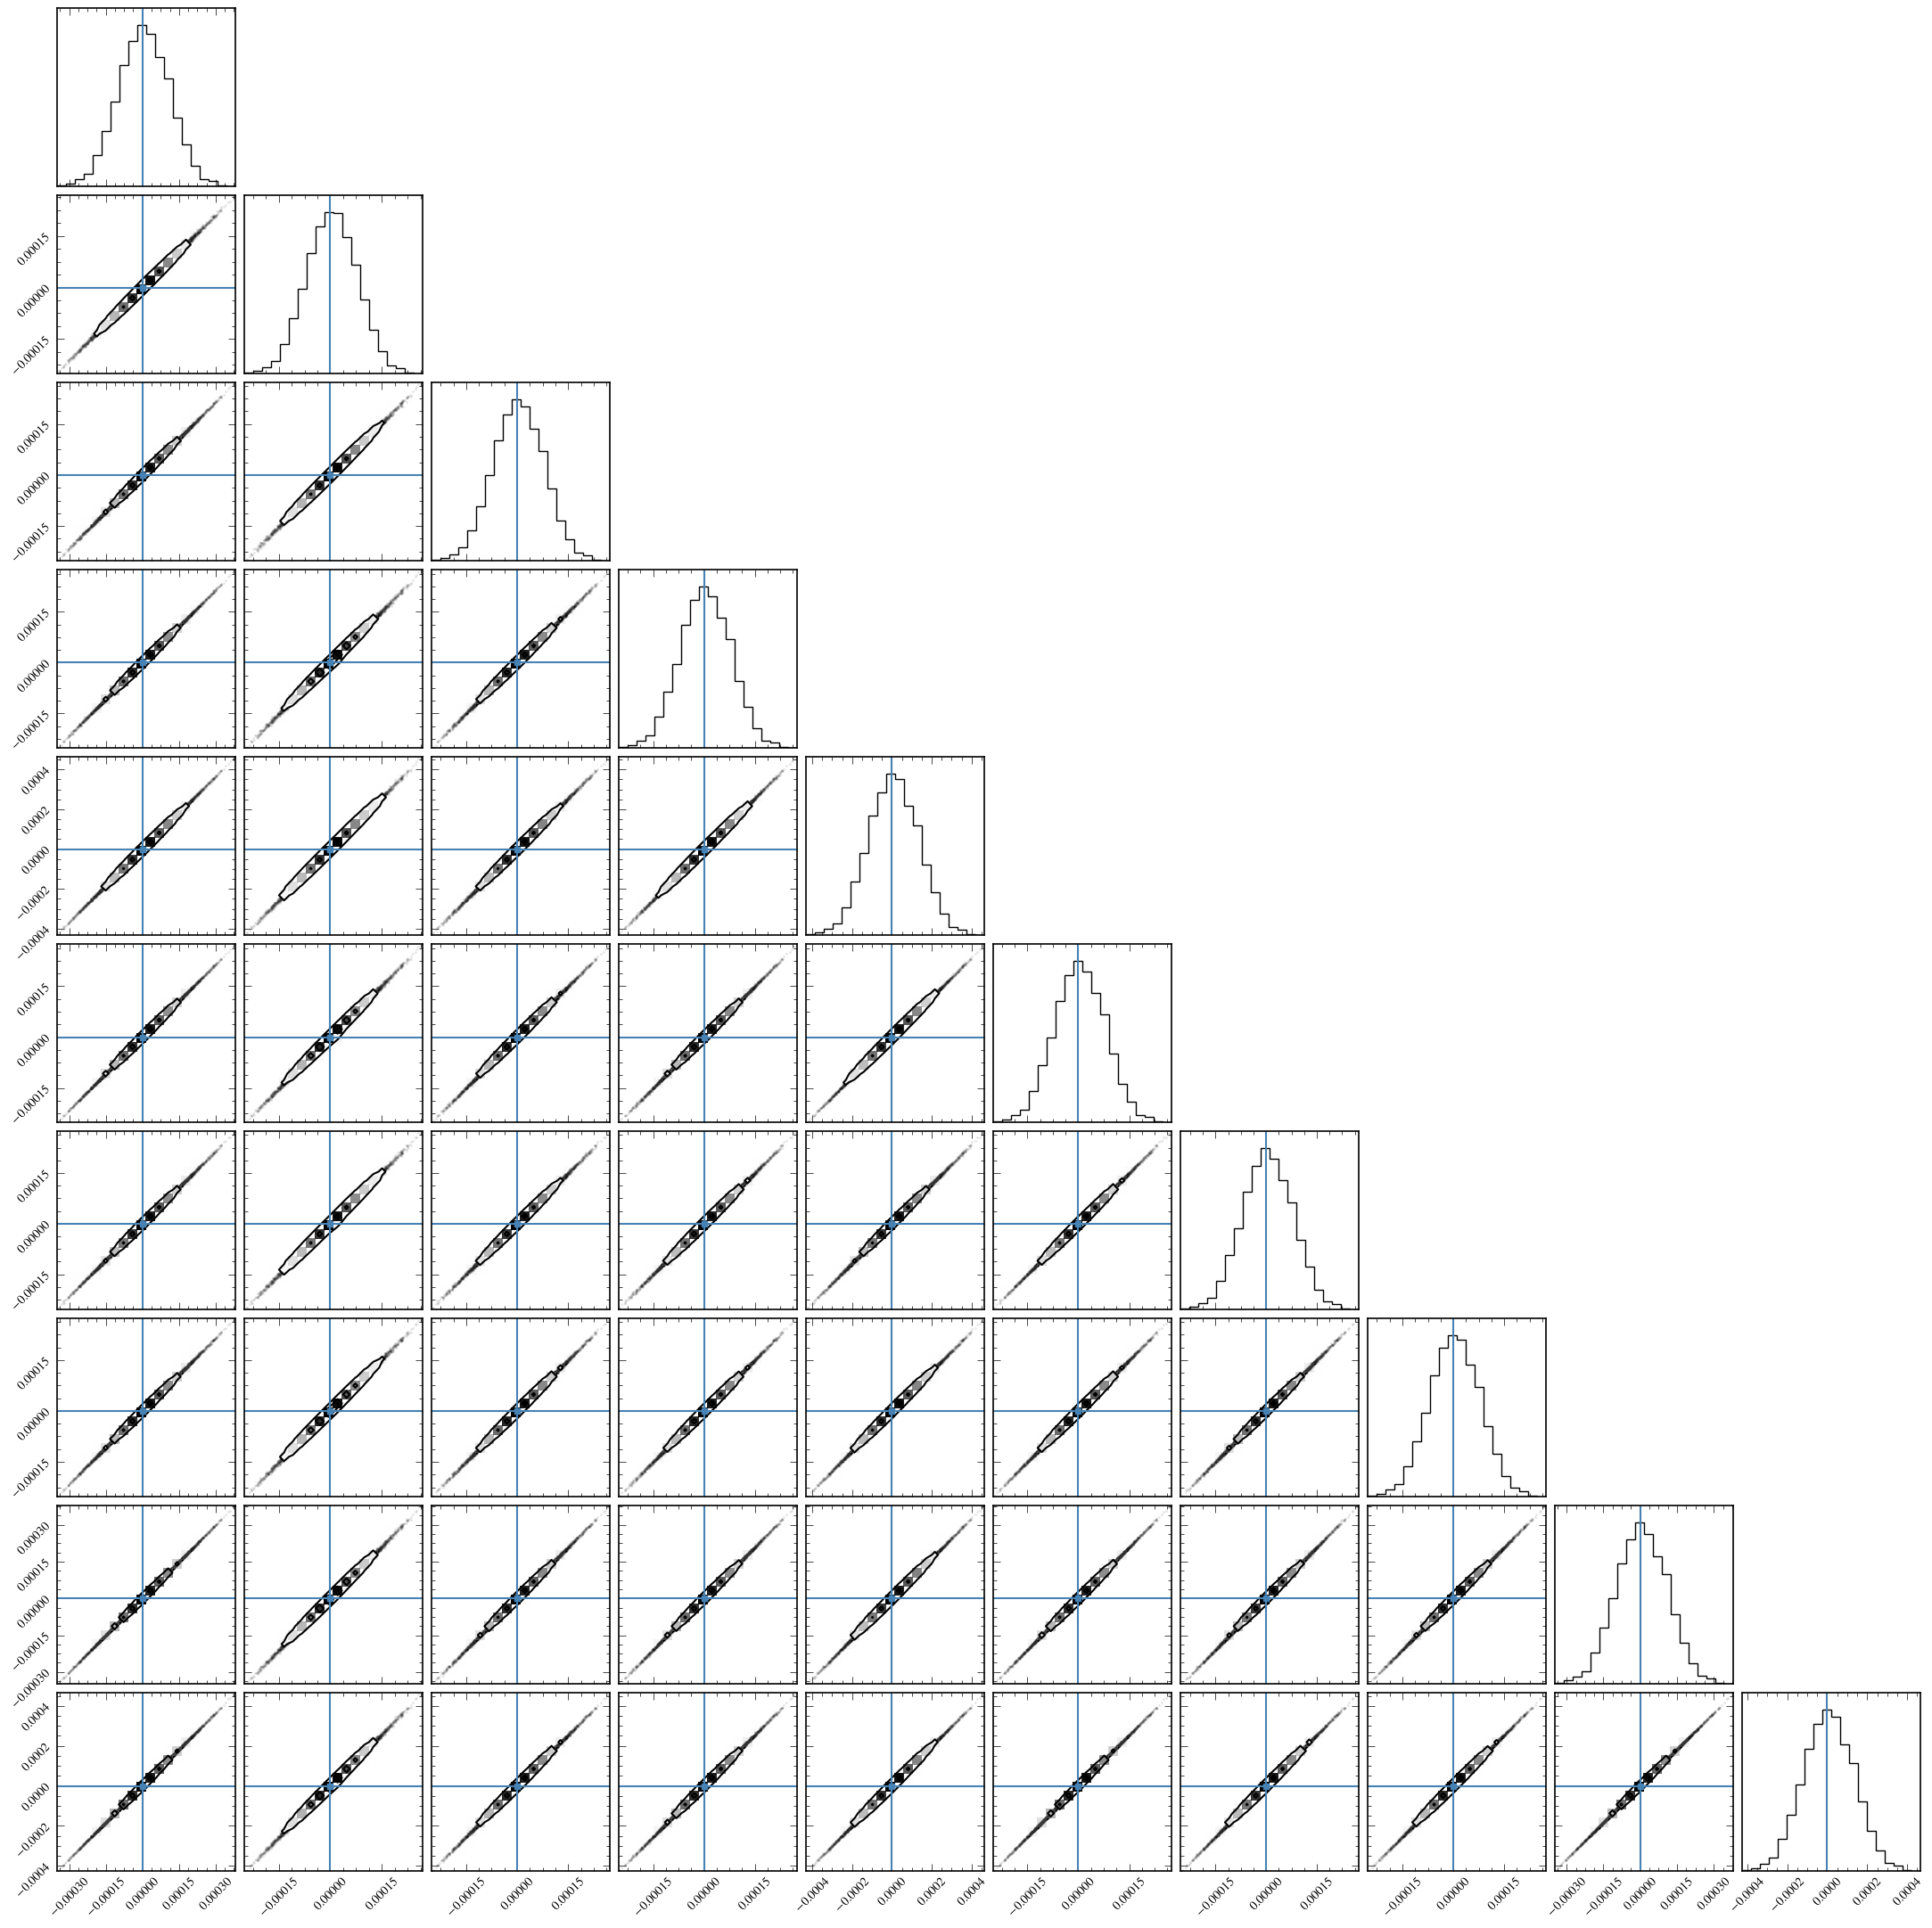

In [49]:
import corner

epsilon = np.array(ent_helpers_samples['a'][:, 0, :-60])
param_ndxs = np.r_[10:20]
fig = corner.corner(data=epsilon[:, param_ndxs],
                    truths=np.zeros(len(param_ndxs)))

In [ ]:
import corner

epsilon = np.array(samples['z_tm_concat'][:, 0, :-60])
param_ndxs = np.r_[10:20]
fig = corner.corner(data=epsilon[:, param_ndxs],
                    hist_kwargs={'density': True},
                    color='C0')
_ = corner.corner(np.random.randn(10_000, len(param_ndxs)),
              hist_kwargs={'density': True},
              fig=fig,
              color='C1')

In [ ]:
mcmc.print_summary()

In [ ]:
# %timeit lnprob0, coeff0 = sig.lnposterior_reparam(helpers = (TNT, TNr), red_params = x0, z = z0)

# Timing Model

### `z_tm` is the value by which the deviations from the best fit are changed. This is an inferable parameter

In [ ]:
z_tm = {}
for pidx in range(sig.npsrs):
    z_tm.update({f'z_{k};{pidx}': 100 * jrandom.normal(jrandom.key(random.randint(0, 16162))) for k in SAMPLE})
z_tm 

In [ ]:
z_tm_concat = jnp.array(list(z_tm.values()))
assert z_tm_concat.shape[0] == len(psrs) * len(SAMPLE)

In [ ]:
tm_model.residuals(z_tm_concat),tm_model.residuals(z_tm_concat).shape

In [ ]:
# %timeit tm_model.residuals(z_tm_concat)

In [ ]:
# z_tm_concat = tm_model.get_epsilon(helpers = (MNM, MNr), key = jrandom.key(12))

In [ ]:
# tm_model.linear_residuals(z_tm_concat)

In [ ]:
tm_param_dim = len(z_tm_concat)
tm_param_dim 

# Sampling

### NOTE: Comment out the parts of the model you do not want to sample

### NOTE: If you want to fix the white noise to the NG15 noise dictionary, make sure you use the white noise dictionary to make the TNT, TNr matricies instead of prior draws.

In [ ]:
def model():

    ######################################## Timing Model ########################################
    # Declare the variables in the model
    z_tm_concat = numpyro.sample('z_tm_concat', dist.Normal(0, 100).expand([tm_param_dim]))
    stochastic_res = tm_model.residuals(z_tm_concat)
    ######################################## White Noise ########################################
    # Declare the variables in the model
    theta_wn = numpyro.sample('theta_wn', dist.Uniform(ll, ul))

    # Update the white noise covaraince matrix
    TNT, TNr, rNr, logdet_N = sig.get_helpers(reff = stochastic_res, 
                                              white_noise_params=theta_wn
                                             )

    # White noise direct contribution to the PTA likelihood
    numpyro.factor('lnpost_white', -0.5 * (rNr[0] + logdet_N))

    ######################################## Red Noise ########################################
    # Declare the variables in the model
    xs = numpyro.sample('xs', dist.Uniform(o.lower_prior_lim_all, o.upper_prior_lim_all)) #PSD params
    z_a = numpyro.sample('z_a', dist.Normal(0, 1).expand((sig.npsrs, sig.nmodes))) #the reparam coefficients

    # evaluate the posterior
    lprob, coeff = sig.lnposterior_reparam(helpers = (TNT, TNr), red_params = xs, z = z_a)
    numpyro.factor('lnpost', lprob)

    numpyro.deterministic('coeff', coeff)

## Not Block Gibbs

In [ ]:
mcmc_bad = MCMC(
    NUTS(model),
    num_warmup=1000,
    num_samples=4000,
    num_chains=1,
    # chain_method=chain_method,
    progress_bar=True
)
mcmc_bad.run(jrandom.key(100))

In [ ]:
samples = mcmc_bad.get_samples()['xs']
samples.shape

In [ ]:
for fidx in range(30):
    plt.hist(samples[:, fidx], **hist_settings)
    plt.show()

## Block Gibbs

In [ ]:
kernel = MultiHMCGibbsWithAnalytic(
        [
        NUTS(model), 
        AnalyticRhoTransition(model = model,
                            posterior_draw_func = tm_model.get_epsilon,
                            prior_draw_func = epsilon_prior_draw
                            rho_site  = "epsilons",
                            coeff_site = "coeff",
                            rho_low  = -9.0,
                            rho_high = -2.0)
        ],
        
        [
        ['z_tm_concat', 'z_a'],
        ['xs']
        ]
    )

kernel = NUTS(model, max_tree_depth=8, target_accept_prob=0.8, dense_mass=False)

In [ ]:
mcmc_bad = MCMC(
    kernel,
    num_warmup=1000,
    num_samples=4000,
    num_chains=1,
    # chain_method=chain_method,
    progress_bar=True
)
mcmc_bad.run(jrandom.key(100))

In [ ]:
samples = mcmc_bad.get_samples()['xs']
samples.shape

In [ ]:
samples[:, -1]

In [ ]:
plt.plot(samples[:, -1])
plt.show()

# ENTERPRISE

In [ ]:
from enterprise_extensions.gibbs_sampling import gibbs

In [ ]:
m = gibbs.BayesPowerSingle(psr=psrs[0],
        Tspan=None,
        select="backend",
        white_vary=True,
        inc_ecorr=True,
        ecorr_type="kernel",
        noise_dict=noise_dict,
        tm_marg=False,
        freq_bins=30,
        tnequad=False,
        log10rhomin=-9.0,
        log10rhomax=-4.0)

In [ ]:
# good_idxs = [psrs[0].fitpars.index('F0'), psrs[0].fitpars.index('F1')] + m.gwid[0].tolist()
good_idxs = [psrs[0].fitpars.index(x) for x in SAMPLE] + m.gwid[0].tolist()
good_idxs = np.array(good_idxs)
# good_idxs = np.arange(m.Tmat.shape[-1])
good_idxs

In [ ]:
keep_idxs = np.ix_(good_idxs, good_idxs)

In [ ]:
# m = gibbs.BayesPowerSingle(psr=psrs[0],
#         Tspan=None,
#         select="backend",
#         white_vary=False,
#         inc_ecorr=True,
#         ecorr_type="kernel",
#         noise_dict=noise_dict,
#         tm_marg=False,
#         freq_bins=30,
#         tnequad=False,
#         log10rhomin=-9.0,
#         log10rhomax=-4.0,
#         keep_coeff_idxs = keep_idxs)

In [ ]:
m.sample(
        niter=int(1e4),
        wniters=30,
        eciters=10,
        savepath='/data/taylor_group/Nima/PandorasBox/Trash/GibbsTrashCan',
        SCAMweight=30,
        AMweight=15,
        DEweight=50,
        covUpdate=1000,
        burn=10000,)

In [ ]:
chain = np.load('/data/taylor_group/Nima/PandorasBox/Trash/GibbsTrashCan/chain_1.npy', mmap_mode = 'r')
chain.shape

In [ ]:
chain = chain[int(0.25 * chain.shape[0]):, :]
chain.shape

In [ ]:
for fidx in range(5):
    plt.plot(chain[:, fidx])
    plt.show()

In [ ]:
chain.shape

In [ ]:
60 + 30 +  tm_model.Mmats[0].shape[-1]

In [ ]:
for fidx in range(30):
    plt.hist(chain[:, fidx], **hist_settings, label = 'ENTERPRISE')
    # plt.hist(samples[:, fidx], **hist_settings, label = 'ATLAS')
    # plt.title(m.pta.param_names[fidx])
    plt.legend()
    plt.show()

# Flows

In [ ]:
from Atlas.flows import Flow

In [ ]:
mm = Flow(data = jnp.array(chain),
        flow_num_layers=4,
        hidden_size=128,
        mlp_num_layers=2,
        num_bins=8,
        learning_rate=1e-4,
        B=6.0,
        p=0.3,
        seed=0
         )

In [ ]:
mm.fit()

In [ ]:
gen_samps = mm.sample((int(1e4)))

In [ ]:
plt.hist(gen_samps[:, 23], **hist_settings)
plt.hist(chain[:, 23], **hist_settings)
plt.show()

In [ ]:
z = mm.backward_pass(gen_samps)
z.shape

In [ ]:
plt.hist(z[:, 23], **hist_settings)
plt.show()

In [ ]:
chain.shape[-1]

In [ ]:
from numpyro.distributions import constraints
from numpyro.distributions.constraints import Constraint
from numpyro.distributions.transforms import Transform
from jax.tree_util import register_pytree_node_class
from numpyro.infer.reparam import ExplicitReparam
from numpyro import handlers

In [ ]:
# @register_pytree_node_class
class FlowReparam(Transform):
    r"""
    """

    domain = constraints.real
    
    def __init__(
        self, flow_object
    ):
        self.flow_object = flow_object
        
    def __call__(self, x):
        return self.flow_object.forward_pass(x)

    def _inverse(self, y):
        return self.flow_object.backward_pass(y)

    def log_abs_det_jacobian(self, x, y, intermediates):
        _, total_logdet = self.flow_object.forward_pass_with_logdet(x)
        return total_logdet

    def tree_flatten(self):
        # flow_object is the dynamic part
        return ((self.flow_object,), None)

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        return cls(*children)

In [ ]:
flow_prior = dist.TransformedDistribution(
    dist.Normal(0,1).expand([chain.shape[-1]]).to_event(1),
    FlowReparam(mm)
)

In [ ]:
def model():
    z = numpyro.sample("z", dist.Normal(0,1).expand([chain.shape[-1]]).to_event(1))
    x, total_logdet = mm.forward_pass_with_logdet(z)
    numpyro.factor('lnprob', mm.log_prob(x) + 0.5 * jnp.sum(z**2) + total_logdet)
    numpyro.deterministic('x', x)
    
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=1000, num_chains=1)
mcmc.run(jrandom.key(2))

In [ ]:
x = mcmc.get_samples()['x']
x.shape

In [ ]:
plt.hist(gen_samps[:, 23], **hist_settings)
plt.hist(x[:, 0, 23],  **hist_settings)
plt.show()

In [ ]:
from enterprise_extensions import blocks
from enterprise.signals import signal_base, gp_signals
from enterprise.pulsar import Pulsar
from astropy.time import TimeDelta
from pint.simulation import make_fake_toas_fromMJDs
import astropy.units as u
from pint.models import get_model

from enterprise_extensions import sampler
from enterprise.signals import parameter
from enterprise.signals import gp_priors

In [ ]:
s = gp_signals.TimingModel(use_svd=True)
s += blocks.white_noise_block(
    vary=True,
    inc_ecorr=True,
    gp_ecorr=False,
    select='backend',
    tnequad=False,
)

# log10_A = parameter.Uniform(-18., -11.)('log10A')
# gamma = parameter.Uniform(0., 7.)('gamma')

# s+= gp_signals.FourierBasisGP(
#     spectrum=gp_priors.powerlaw(log10_A=log10_A, gamma = gamma),
#     modes = sig_unc.freqs,
#     # components = len(sig_unc.freqs),
#     Tspan=Tspan,
#     name="red_noise",
# )
log10_rho = parameter.Uniform(-9., -2., size=len(sig_unc.freqs))
s+= gp_signals.FourierBasisGP(
    spectrum=gp_priors.free_spectrum(log10_rho=log10_rho),
    components=len(sig_unc.freqs),
    modes = sig_unc.freqs,
    Tspan=Tspan,
    # name="red_noise",
)

pta = signal_base.PTA(
    [s(p) for p in psrs], signal_base.LogLikelihoodDenseCholesky
)


In [ ]:
# pta.set_default_params(noise_dict)

In [ ]:
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc

In [ ]:
# ent_samp = sampler.setup_sampler(
#     pta,
#     # x0_user = np.hstack([p.sample() for p in pta.params]),
#     outdir="/data/taylor_group/Nima/PandorasBox/Trash/TrashCan",
#     resume=False,
#     empirical_distr=None,
#     groups=None,
#     human=None,
#     save_ext_dists=False,
#     loglkwargs={},
#     logpkwargs={},
# )
# set initial parameters drawn from prior
x0 = np.hstack([p.sample() for p in pta.params])
ndim = len(x0)
cov = np.diag(np.ones(ndim) * 0.01**2)
ent_samp = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, 
                 outDir='/data/taylor_group/Nima/PandorasBox/Trash/GibbsTrashCan', resume=False)

In [ ]:
ent_samp.sample(
    p0 = np.hstack([p.sample() for p in pta.params]),
    Niter = int(2e5),
    SCAMweight=30,
    AMweight=15,
    DEweight=50,
)

In [ ]:
chain = np.loadtxt('/data/taylor_group/Nima/PandorasBox/Trash/GibbsTrashCan/chain_1.txt')
chain = chain[int(0.25 * chain.shape[0]):, :-4]
chain.shape

In [ ]:
for fidx in range(6, 36):
    plt.hist(chain[:, fidx], **hist_settings)
    plt.hist(samples[:, fidx - 6], **hist_settings)
    plt.title(pta.param_names[fidx])
    plt.show()